# B-factor analysis.

In [1]:
import  numpy as np
import matplotlib        as mpl
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import scipy.stats

sns.set_style("ticks")

mpl.rcParams['font.family'] = ['serif']
mpl.rcParams['mathtext.fontset'] = 'dejavuserif'
mpl.rcParams['font.size'] = 8.

cm = 1/2.54  # centimeters in inches
colors = ["#F9D9D8", "#EDA3B2", "#7E73AC"]

In [2]:
def load_bfactor(sysname: str):
  with open(f"./zcsvs/{sysname}_bfactors.csv", 'r') as f:
    lines = f.readlines()[1:]
    resid = [int(_.split(',')[0]) for _ in lines]
    mean_exp  = np.asarray([float(_.split(',')[1]) for _ in lines])
    mean_aflf = np.asarray([float(_.split(',')[2]) for _ in lines])
    mean_afs2 = np.asarray([float(_.split(',')[4]) for _ in lines])
    mean_bemu = np.asarray([float(_.split(',')[6]) for _ in lines])
    std_aflf  = np.asarray([float(_.split(',')[3]) for _ in lines])
    std_afs2  = np.asarray([float(_.split(',')[5]) for _ in lines])
    std_bemu  = np.asarray([float(_.split(',')[7]) for _ in lines])
  with open(f"./zcsvs/taus.csv", 'r') as f:
    for line in f.readlines():
      words = line.split(',')
      if words[0].strip()==sysname and words[1].strip()=='aftools':
        tau_aflf = float(words[2].strip())
      if words[0].strip()==sysname and words[1].strip()=='afsample2':
        tau_afs2 = float(words[2].strip())
      if words[0].strip()==sysname and words[1].strip()=='bioemu':
        tau_bemu = float(words[2].strip())
        
  return (resid, (mean_exp, ), 
          (mean_aflf, std_aflf, tau_aflf), 
          (mean_afs2, std_afs2, tau_afs2),
          (mean_bemu, std_bemu, tau_bemu), )


9.999999999999998 9.999999999999998
0.0 71.81
2 282
0 394
43 5336
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96]


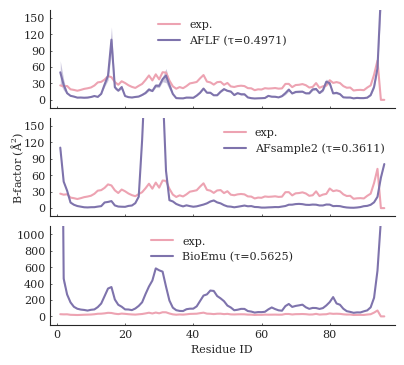

In [16]:
figspec= {'lmargin': 1  *cm, 
          'rmargin': 1/4*cm,
          'hgap':    1/4*cm,
          'hsize':  35/4*cm,
          'bmargin': 1  *cm,
          'tmargin': 1  *cm,
          'vgap':    1/4*cm,
          'vsize':  10/4*cm,}

sysnames = {"BPTI"  : ( -5,  55, 10, -200, 2200,  400), 
            "P00644": (-25, 275, 50, -150, 1650,  300), 
            "P00648": (-15, 165, 30, - 50,  550,  100), 
            "P00698": ( -5,  55, 10, - 20,  220,   40), 
            "P01854": (-15, 165, 30, - 50,  550,  100), 
            "P06654": ( -5,  55, 10, -500, 5500, 1000), 
            "P61823": (-10, 110, 20, -150, 1650,  300), 
            "P62937": (-10, 110, 20, - 50,  550,  100), 
            "PDZ2"  : (-15, 165, 30, -100, 1100,  200), }
sysname = "PDZ2"

figsize = (figspec['lmargin'] + figspec['hsize'] + (figspec['hgap']+figspec['hsize'])*0 + figspec['rmargin'], 
           figspec['bmargin'] + figspec['vsize'] + (figspec['vgap']+figspec['vsize'])*2 + figspec['tmargin'], )
print(figsize[0]/cm, figsize[1]/cm)

fig, axes = plt.subplots(3, 1, figsize=figsize, sharex=True, 
    gridspec_kw=dict(left  =figspec['lmargin']/figsize[0], right=1.-figspec['rmargin']/figsize[0],
                     bottom=figspec['bmargin']/figsize[1], top  =1.-figspec['tmargin']/figsize[1],
                     wspace=figspec['hgap']/figspec['hsize'],
                     hspace=figspec['vgap']/figspec['vsize'], ))


resid, (mean_exp,), (mean_aflf, std_aflf, tau_bft), (mean_afs2, std_afs2, tau_afs2), (mean_bemu, std_bemu, tau_bemu) = load_bfactor(sysname=sysname)
print(min(mean_exp), max(mean_exp))
print(int(min(mean_aflf)), int(max(mean_aflf)))
print(int(min(mean_afs2)), int(max(mean_afs2)))
print(int(min(mean_bemu)), int(max(mean_bemu)))

for ax in axes:
  ax.minorticks_off()
  ax.spines[['top','right']].set_visible(False)
  ax.tick_params(direction='in', width=.5, length=1.5, axis='both', labelsize=8)
  ax.set(ylim=(sysnames[sysname][0], sysnames[sysname][1]), yticks=list(range(0, sysnames[sysname][1]-1, sysnames[sysname][2])), 
         xlim=(min(resid)-3, max(resid)+3), )
  
print(resid)
axes[0].plot(resid, mean_exp, color=colors[1], label='exp.')
axes[0].plot(resid, mean_aflf, color=colors[2], label=f'AFLF (τ={float(tau_bft):.4f})')
axes[0].fill_between(resid, mean_aflf - std_aflf, mean_aflf + std_aflf, color=colors[2], alpha=0.4, lw=0)
axes[0].legend(frameon=False)

axes[1].plot(resid, mean_exp, color=colors[1], label='exp.')
axes[1].plot(resid, mean_afs2, color=colors[2], label=f'AFsample2 (τ={float(tau_afs2):.4f})')
axes[1].fill_between(resid, mean_afs2 - std_afs2, mean_afs2 + std_afs2, color=colors[2], alpha=0.4, lw=0)
axes[1].legend(frameon=False)

axes[2].plot(resid, mean_exp, color=colors[1], label='exp.')
axes[2].plot(resid, mean_bemu, color=colors[2], label=f'BioEmu (τ={float(tau_bemu):.4f})')
axes[2].fill_between(resid, mean_bemu - std_bemu, mean_bemu + std_bemu, color=colors[2], alpha=0.4, lw=0)
axes[2].legend(frameon=False)
axes[2].set(ylim=(sysnames[sysname][3], sysnames[sysname][4]), yticks=list(range(0, sysnames[sysname][4]-1, sysnames[sysname][5])),)

axes[1].set_ylabel(r'B-factor (Å$^2$)', fontsize=8, va='center')
axes[2].set_xlabel(r'Residue ID', fontsize=8, ha='center')
plt.savefig(f'./zfigures/fig_bfactor_{sysname}.jpg', dpi=600)

15.0 5.0


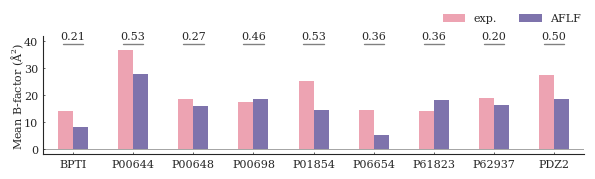

In [12]:
figspec= {'lmargin': 1  *cm, 
          'rmargin': 1/4*cm,
          'hgap':    1/4*cm,
          'hsize':  55/4*cm,
          'bmargin': 1  *cm,
          'tmargin': 1  *cm,
          'vgap':    1  *cm,
          'vsize':   12/4*cm,}

figsize = (figspec['lmargin'] + figspec['hsize'] + (figspec['hgap']+figspec['hsize'])*0 + figspec['rmargin'], 
           figspec['bmargin'] + figspec['vsize'] + (figspec['vgap']+figspec['vsize'])*0 + figspec['tmargin'], )
print(figsize[0]/cm, figsize[1]/cm)

all_bfactors = [load_bfactor(sysname=s) for s in sysnames]
exp_bft = [_[1][0] for _ in all_bfactors]
sim_bft = [_[2][0] for _ in all_bfactors]
tau_bft = [_[2][2] for _ in all_bfactors]

fig, ax = plt.subplots(1, 1, figsize=figsize, sharex=True, 
    gridspec_kw=dict(left  =figspec['lmargin']/figsize[0], right=1.-figspec['rmargin']/figsize[0],
                     bottom=figspec['bmargin']/figsize[1], top  =1.-figspec['tmargin']/figsize[1],
                     wspace=figspec['hgap']/figspec['hsize'],
                     hspace=figspec['vgap']/figspec['vsize'], ))

ax.axhline(y=0, color='#808080', ls='-', lw=0.5, zorder=0)
ax.bar(np.arange(9)-.125, [np.mean(_) for _ in exp_bft], width=.25, lw=0., color=colors[1], label='exp.')
ax.bar(np.arange(9)+.125, [np.mean(_) for _ in sim_bft], width=.25, lw=0., color=colors[2], label='AFLF')
for _ in range(9):
  ax.plot([_-.17, _+.17], [39., 39.], color='#808080', ls='-', lw=1.)
  ax.text(_, 40, f'{tau_bft[_]:.2f}', va='bottom', ha='center')

ax.minorticks_off()
ax.spines[['top','right']].set_visible(False)
ax.tick_params(direction='in', width=.5, length=1.5, axis='both', labelsize=8)
ax.set(ylim=(-2, 42), yticks=list(range(0, 41, 10)),
       xlim=(-.5, 8.5), xticks=np.arange(9), xticklabels=sysnames)
ax.set_ylabel(r'Mean B-factor (Å$^2$)', fontsize=8, va='center')
ax.legend(frameon=False, ncol=2, bbox_to_anchor=(.72, 1.02))
plt.savefig(f'./zfigures/fig_bfactor_all_aflf.jpg', dpi=600)

15.0 5.0


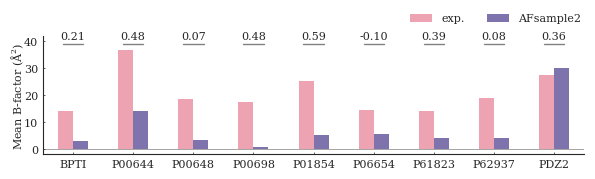

In [13]:
figspec= {'lmargin': 1  *cm, 
          'rmargin': 1/4*cm,
          'hgap':    1/4*cm,
          'hsize':  55/4*cm,
          'bmargin': 1  *cm,
          'tmargin': 1  *cm,
          'vgap':    1  *cm,
          'vsize':   12/4*cm,}

figsize = (figspec['lmargin'] + figspec['hsize'] + (figspec['hgap']+figspec['hsize'])*0 + figspec['rmargin'], 
           figspec['bmargin'] + figspec['vsize'] + (figspec['vgap']+figspec['vsize'])*0 + figspec['tmargin'], )
print(figsize[0]/cm, figsize[1]/cm)

all_bfactors = [load_bfactor(sysname=s) for s in sysnames]
exp_bft = [_[1][0] for _ in all_bfactors]
sim_bft = [_[3][0] for _ in all_bfactors]
tau_bft = [_[3][2] for _ in all_bfactors]

fig, ax = plt.subplots(1, 1, figsize=figsize, sharex=True, 
    gridspec_kw=dict(left  =figspec['lmargin']/figsize[0], right=1.-figspec['rmargin']/figsize[0],
                     bottom=figspec['bmargin']/figsize[1], top  =1.-figspec['tmargin']/figsize[1],
                     wspace=figspec['hgap']/figspec['hsize'],
                     hspace=figspec['vgap']/figspec['vsize'], ))

ax.axhline(y=0, color='#808080', ls='-', lw=0.5, zorder=0)
ax.bar(np.arange(9)-.125, [np.mean(_) for _ in exp_bft], width=.25, lw=0., color=colors[1], label='exp.')
ax.bar(np.arange(9)+.125, [np.mean(_) for _ in sim_bft], width=.25, lw=0., color=colors[2], label='AFsample2')
for _ in range(9):
  ax.plot([_-.17, _+.17], [39., 39.], color='#808080', ls='-', lw=1.)
  ax.text(_, 40, f'{tau_bft[_]:.2f}', va='bottom', ha='center')

ax.minorticks_off()
ax.spines[['top','right']].set_visible(False)
ax.tick_params(direction='in', width=.5, length=1.5, axis='both', labelsize=8)
ax.set(ylim=(-2, 42), yticks=list(range(0, 41, 10)),
       xlim=(-.5, 8.5), xticks=np.arange(9), xticklabels=sysnames)
ax.set_ylabel(r'Mean B-factor (Å$^2$)', fontsize=8, va='center')
ax.legend(frameon=False, ncol=2, bbox_to_anchor=(.66, 1.02))
plt.savefig(f'./zfigures/fig_bfactor_all_afs2.jpg', dpi=600)

15.0 5.0


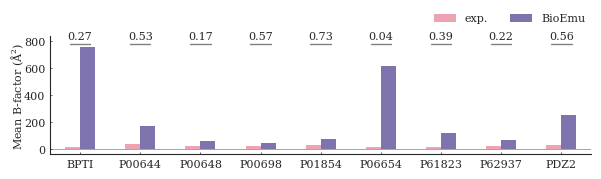

In [14]:
figspec= {'lmargin': 1  *cm, 
          'rmargin': 1/4*cm,
          'hgap':    1/4*cm,
          'hsize':  55/4*cm,
          'bmargin': 1  *cm,
          'tmargin': 1  *cm,
          'vgap':    1  *cm,
          'vsize':   12/4*cm,}

figsize = (figspec['lmargin'] + figspec['hsize'] + (figspec['hgap']+figspec['hsize'])*0 + figspec['rmargin'], 
           figspec['bmargin'] + figspec['vsize'] + (figspec['vgap']+figspec['vsize'])*0 + figspec['tmargin'], )
print(figsize[0]/cm, figsize[1]/cm)

all_bfactors = [load_bfactor(sysname=s) for s in sysnames]
exp_bft = [_[1][0] for _ in all_bfactors]
sim_bft = [_[4][0] for _ in all_bfactors]
tau_bft = [_[4][2] for _ in all_bfactors]

fig, ax = plt.subplots(1, 1, figsize=figsize, sharex=True, 
    gridspec_kw=dict(left  =figspec['lmargin']/figsize[0], right=1.-figspec['rmargin']/figsize[0],
                     bottom=figspec['bmargin']/figsize[1], top  =1.-figspec['tmargin']/figsize[1],
                     wspace=figspec['hgap']/figspec['hsize'],
                     hspace=figspec['vgap']/figspec['vsize'], ))

ax.axhline(y=0, color='#808080', ls='-', lw=0.5, zorder=0)
ax.bar(np.arange(9)-.125, [np.mean(_) for _ in exp_bft], width=.25, lw=0., color=colors[1], label='exp.')
ax.bar(np.arange(9)+.125, [np.mean(_) for _ in sim_bft], width=.25, lw=0., color=colors[2], label='BioEmu')
for _ in range(9):
  ax.plot([_-.17, _+.17], [780., 780.], color='#808080', ls='-', lw=1.)
  ax.text(_, 800, f'{tau_bft[_]:.2f}', va='bottom', ha='center')

ax.minorticks_off()
ax.spines[['top','right']].set_visible(False)
ax.tick_params(direction='in', width=.5, length=1.5, axis='both', labelsize=8)
ax.set(ylim=(-40, 840), yticks=list(range(0, 801, 200)),
       xlim=(-.5, 8.5), xticks=np.arange(9), xticklabels=sysnames)
ax.set_ylabel(r'Mean B-factor (Å$^2$)', fontsize=8, va='center')
ax.legend(frameon=False, ncol=2, bbox_to_anchor=(.69, 1.02))
plt.savefig(f'./zfigures/fig_bfactor_all_bioemu.jpg', dpi=600)